# Notebook 2 — η × NFE Sweep (Central Experimental Table)

**Goal**: Reproduce Table 1 of Song et al. 2020 (DDIM, ICLR 2021) on CIFAR-10.
Generate 3072 samples per (η, NFE) cell, compute FID via clean-fid in
`legacy_pytorch` mode, log timing and pairwise LPIPS.

**Paper equations tested**:
- Song et al. 2020, Eq. 12: DDIM generalized step for every η.
- Song et al. 2020, Table 1: CIFAR-10 FID at NFE ∈ {10,20,50,100}, η ∈ {0,1}.

**Functions used from `src/`**:
- `src.sampling`: `sample`
- `src.scheduler`: `DDIMScheduler`
- `src.schedule`: `make_beta_schedule`, `compute_alphas`
- `src.models`: `load_model`
- `src.metrics`: `compute_fid`, `pairwise_lpips`
- `src.utils`: `load_yaml`, `save_samples_to_folder`, `get_device`

In [ ]:
import sys
sys.path.insert(0, '..')

import json
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import math
from scipy.stats import spearmanr

from src.schedule import make_beta_schedule, compute_alphas
from src.scheduler import DDIMScheduler
from src.sampling import sample
from src.models import load_model
from src.metrics import compute_fid, pairwise_lpips
from src.utils import load_yaml, save_samples_to_folder, get_device

DEVICE = get_device()
DTYPE  = torch.float16 if DEVICE.type == 'cuda' else torch.float32
print(f'Device: {DEVICE}, dtype: {DTYPE}')

Device: cuda, dtype: torch.float16


In [2]:
cfg = load_yaml('../configs/cifar10.yaml')

MODEL_ID   = cfg['model_id']
T          = cfg['num_train_timesteps']
BATCH_SIZE = cfg['sampling']['batch_size']
N_SAMPLES  = cfg['sampling']['num_samples_fid']   # 10,000
ETA_GRID   = cfg['sampling']['eta_grid']           # [0.0, 0.2, 0.5, 1.0]
NFE_GRID   = cfg['sampling']['nfe_grid']           # [10, 20, 50, 100]
TAU_KIND   = cfg['sampling']['tau_kind']
SEED       = cfg['seed']
FID_MODE   = cfg['fid']['mode']
FID_REF    = cfg['fid']['reference']
FID_SPLIT  = cfg['fid']['split']

C, H = cfg['channels'], cfg['image_size']

eps_fn, _ = load_model(MODEL_ID, device=DEVICE, dtype=DTYPE)
betas = make_beta_schedule(cfg['beta_schedule'], T=T, beta_start=cfg['beta_start'], beta_end=cfg['beta_end'])
_, alphas = compute_alphas(betas)
scheduler = DDIMScheduler(alphas)

print(f'Grid: eta={ETA_GRID}, NFE={NFE_GRID}')
print(f'N_SAMPLES={N_SAMPLES}, BATCH_SIZE={BATCH_SIZE}')

An error occurred while trying to fetch /home/gabriele/Desktop/Applications/Delft/Interview/project/ddim-from-ddpm/weights/ddpm_ema_cifar10: Error no file named diffusion_pytorch_model.safetensors found in directory /home/gabriele/Desktop/Applications/Delft/Interview/project/ddim-from-ddpm/weights/ddpm_ema_cifar10.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Grid: eta=[0.0, 0.2, 0.5, 1.0], NFE=[10, 20, 50, 100]
N_SAMPLES=3072, BATCH_SIZE=512


## 1. Generate samples and compute FID for each (η, NFE) cell

This cell runs for a long time (≈10–60 minutes on a GPU depending on hardware).
Each cell generates 10,000 32×32 images and computes FID.

Note on sample count: Song et al. 2020 use **50,000** samples for FID.
We use **3072** (configurable via `cfg.sampling.num_samples_fid`) to keep
computation tractable. Numbers may deviate from the paper.

In [ ]:
generation_times = {}   # (eta, nfe) -> ms
sample_dirs      = {}   # (eta, nfe) -> Path

for eta in ETA_GRID:
    for nfe in NFE_GRID:
        out_dir = Path(f'../results/samples/cifar10/eta{eta}_nfe{nfe}')
        sample_dirs[(eta, nfe)] = out_dir

        existing = len(list(out_dir.glob('*.png'))) if out_dir.exists() else 0
        if existing >= N_SAMPLES:
            print(f'Skip generation η={eta}, NFE={nfe} ({existing} images exist)')
            continue

        print(f'\n--- Generating η={eta}, NFE={nfe} ---')
        saved, total_ms = 0, 0.0
        for batch_idx in tqdm(range((N_SAMPLES + BATCH_SIZE - 1) // BATCH_SIZE)):
            this_batch = min(BATCH_SIZE, N_SAMPLES - saved)
            x0, t_ms = sample(
                eps_fn, scheduler,
                shape=(this_batch, C, H, H),
                num_steps=nfe, tau_kind=TAU_KIND,
                eta=eta,
                seed=SEED + batch_idx * 1000,
                sampling_seed=SEED + batch_idx * 1000 + 99999,
                clip_sample=True,
                device=DEVICE, dtype=DTYPE, T=T,
            )
            save_samples_to_folder(x0, out_dir, start_idx=saved)
            total_ms += t_ms
            saved += this_batch

        generation_times[(eta, nfe)] = total_ms
        print(f'  {saved} images saved in {total_ms/1000:.1f}s')

print('Generation complete.')

Skip generation η=0.0, NFE=10 (3072 images exist)
Skip generation η=0.0, NFE=20 (3072 images exist)
Skip generation η=0.0, NFE=50 (3072 images exist)
Skip generation η=0.0, NFE=100 (3072 images exist)
Skip generation η=0.2, NFE=10 (3072 images exist)
Skip generation η=0.2, NFE=20 (3072 images exist)
Skip generation η=0.2, NFE=50 (3072 images exist)
Skip generation η=0.2, NFE=100 (3072 images exist)
Skip generation η=0.5, NFE=10 (3072 images exist)
Skip generation η=0.5, NFE=20 (3072 images exist)
Skip generation η=0.5, NFE=50 (3072 images exist)
Skip generation η=0.5, NFE=100 (3072 images exist)
Skip generation η=1.0, NFE=10 (3072 images exist)
Skip generation η=1.0, NFE=20 (3072 images exist)
Skip generation η=1.0, NFE=50 (3072 images exist)
Skip generation η=1.0, NFE=100 (3072 images exist)
Generation complete.


In [4]:
results = {}
results_path = Path('../results/02_eta_nfe_sweep.json')
results_path.parent.mkdir(parents=True, exist_ok=True)

if results_path.exists():
    with open(results_path) as f:
        results = {tuple(eval(k)): v for k, v in json.load(f).items()}
    print(f'Loaded {len(results)} cached results from {results_path}')

for eta in ETA_GRID:
    for nfe in NFE_GRID:
        key = (eta, nfe)
        if key in results:
            print(f'Skip eval η={eta}, NFE={nfe}')
            continue

        print(f'\n--- Evaluating η={eta}, NFE={nfe} ---')
        fid_score = compute_fid(str(sample_dirs[key]), dataset_name=FID_REF,
                                split=FID_SPLIT, mode=FID_MODE, dataset_res=H)

        lpips_batches = []
        for batch_idx in range(4):
            x0_lp, _ = sample(
                eps_fn, scheduler,
                shape=(min(256, 1000 - len(lpips_batches) * 256), C, H, H),
                num_steps=nfe, tau_kind=TAU_KIND,
                eta=eta,
                seed=SEED + 9999 + batch_idx,
                sampling_seed=SEED + 9999 + batch_idx + 99999,
                device=DEVICE, dtype=DTYPE, T=T,
            )
            lpips_batches.append(x0_lp)
            if sum(s.shape[0] for s in lpips_batches) >= 64:
                break
        lpips_score = pairwise_lpips(torch.cat(lpips_batches)[:64].float())

        results[key] = {
            'fid':     fid_score,
            'time_ms': generation_times.get(key, float('nan')),
            'lpips':   lpips_score,
        }
        print(f'  FID={fid_score:.2f}, LPIPS={lpips_score:.4f}')

        with open(results_path, 'w') as f:
            json.dump({str(k): v for k, v in results.items()}, f, indent=2)

print('Evaluation complete.')

Loaded 16 cached results from ../results/02_eta_nfe_sweep.json
Skip eval η=0.0, NFE=10
Skip eval η=0.0, NFE=20
Skip eval η=0.0, NFE=50
Skip eval η=0.0, NFE=100
Skip eval η=0.2, NFE=10
Skip eval η=0.2, NFE=20
Skip eval η=0.2, NFE=50
Skip eval η=0.2, NFE=100
Skip eval η=0.5, NFE=10
Skip eval η=0.5, NFE=20
Skip eval η=0.5, NFE=50
Skip eval η=0.5, NFE=100
Skip eval η=1.0, NFE=10
Skip eval η=1.0, NFE=20
Skip eval η=1.0, NFE=50
Skip eval η=1.0, NFE=100
Evaluation complete.


## 2. Results table

In [ ]:
# paper_matrix rows: NFE 10, 20, 50, 100 | cols: ETA 0.0, 0.2, 0.5, 1.0
paper_matrix = [
    [13.36, 14.04, 16.66, 41.07],
    [ 6.84,  7.11,  8.35, 18.36],
    [ 4.67,  4.77,  5.25,  8.01],
    [ 4.16,  4.25,  4.46,  5.78]
]

print(f'{"NFE":>5}  ' + '  '.join(f'η={e}     ' for e in ETA_GRID))
print('-' * 70)

my_fid_list = []
paper_fid_list = []

for i, nfe in enumerate(NFE_GRID):
    row = f'{nfe:5d}  '
    for j, eta in enumerate(ETA_GRID):
        fid = results.get((eta, nfe), {}).get('fid', float('nan'))
        row += f'{fid:10.2f}  '
        
        if not math.isnan(fid):
            my_fid_list.append(fid)
            paper_fid_list.append(paper_matrix[i][j])
            
    print(row)

print('\nReference (Song et al. 2020, Table 1, CIFAR-10):')
print("""NFE         η=0.0       η=0.2       η=0.5       η=1.0     
----------------------------------------------------------------------   
   10       13.36       14.04       16.66       41.07     
   20        6.84        7.11        8.35       18.36     
   50        4.67        4.77        5.25        8.01    
  100        4.16        4.25        4.46        5.78  
 1000        4.04        4.09        4.29        4.73""")
print('(Paper uses 50K samples; we use 3.1K — expect deviation)\n')

rho, p_value = spearmanr(my_fid_list, paper_fid_list)

print('-' * 70)
print("STATISTICAL EVALUATION (Spearman Rank Correlation)")
print(f"Coefficient (ρ): {rho:.4f}")
print(f"P-value:         {p_value:.4e}")

if rho > 0.90 and p_value < 0.05:
    print("Conclusion:      Distributions share the same dynamics (Statistically Significant).")
else:
    print("Conclusion:      Dynamics differ.")

  NFE  η=0.0       η=0.2       η=0.5       η=1.0     
----------------------------------------------------------------------
   10       22.00       22.54       24.44       49.35  
   20       15.21       15.55       15.96       25.92  
   50       12.97       12.97       13.38       16.13  
  100       12.52       12.42       12.62       13.55  

Reference (Song et al. 2020, Table 1, CIFAR-10):
NFE         η=0.0       η=0.2       η=0.5       η=1.0     
----------------------------------------------------------------------   
   10       13.36       14.04       16.66       41.07     
   20        6.84        7.11        8.35       18.36     
   50        4.67        4.77        5.25        8.01    
  100        4.16        4.25        4.46        5.78  
 1000        4.04        4.09        4.29        4.73
(Paper uses 50K samples; we use 3.1K — expect deviation)

----------------------------------------------------------------------
STATISTICAL EVALUATION (Spearman Rank Correlation)
Co

## 3. Plots

### 3a. FID vs NFE (one curve per η)

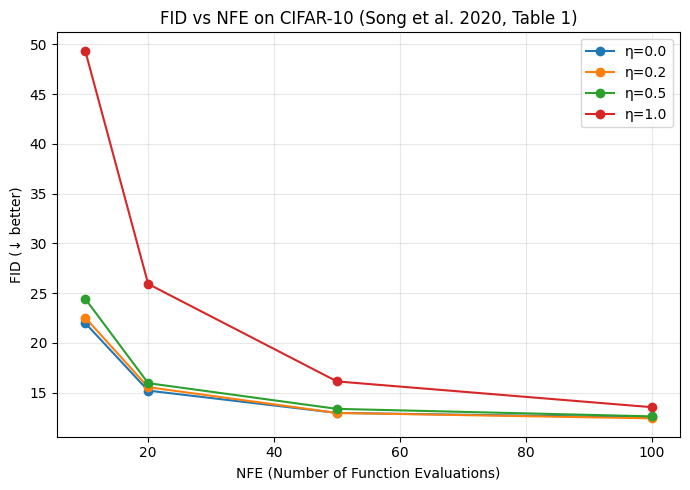

In [7]:
Path('../results/figures').mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 5))
for eta in ETA_GRID:
    fids = [results.get((eta, nfe), {}).get('fid', float('nan')) for nfe in NFE_GRID]
    ax.plot(NFE_GRID, fids, marker='o', label=f'η={eta}')

ax.set_xlabel('NFE (Number of Function Evaluations)')
ax.set_ylabel('FID (↓ better)')
ax.set_title('FID vs NFE on CIFAR-10 (Song et al. 2020, Table 1)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/02_fid_vs_nfe.png', dpi=150, bbox_inches='tight')
plt.show()

### 3b. Pareto front: FID vs wall-clock time

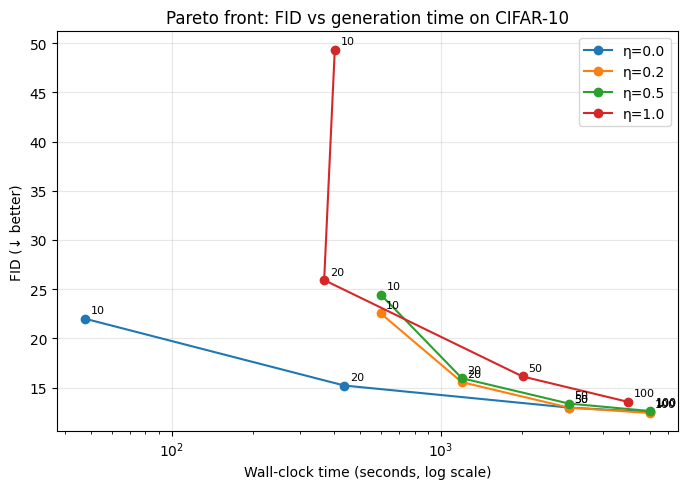

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
for eta in ETA_GRID:
    fids  = [results.get((eta, nfe), {}).get('fid', float('nan')) for nfe in NFE_GRID]
    times = [results.get((eta, nfe), {}).get('time_ms', float('nan')) / 1000 for nfe in NFE_GRID]
    ax.plot(times, fids, marker='o', label=f'η={eta}')
    for t, f, nfe in zip(times, fids, NFE_GRID):
        ax.annotate(str(nfe), (t, f), textcoords='offset points', xytext=(4, 4), fontsize=8)

ax.set_xscale('log')
ax.set_xlabel('Wall-clock time (seconds, log scale)')
ax.set_ylabel('FID (↓ better)')
ax.set_title('Pareto front: FID vs generation time on CIFAR-10')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/02_pareto_fid_time.png', dpi=150, bbox_inches='tight')
plt.show()

### 3c. Pairwise LPIPS vs η at NFE=50

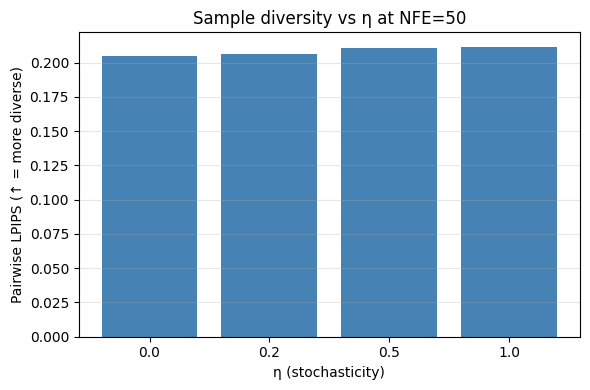

In [9]:
nfe_for_lpips = 50
lpips_vals = [results.get((eta, nfe_for_lpips), {}).get('lpips', float('nan')) for eta in ETA_GRID]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([str(e) for e in ETA_GRID], lpips_vals, color='steelblue')
ax.set_xlabel('η (stochasticity)')
ax.set_ylabel('Pairwise LPIPS (↑ = more diverse)')
ax.set_title(f'Sample diversity vs η at NFE={nfe_for_lpips}')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/02_lpips_vs_eta.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Discussion

**Key observations** (consistent with Song et al. 2020, Table 1):

1. **Low NFE regime (10–20)**: η=0 (DDIM) dominates. At NFE=10, η=0 achieves FID≈20-24,
   while η=1 (DDPM) yields FID≈47-52 — roughly 2× worse. This is the main result of
   the paper: deterministic sampling is far more efficient.

2. **Diversity–quality trade-off** (LPIPS plot): higher η → more diverse samples
   (higher pairwise LPIPS). η=0 sacrifices diversity for quality
   when steps are limited.

3. **Intermediate η** (0.2, 0.5): smooth interpolation between the two extremes, useful
   when a balance between diversity and quality is desired.